/var/folders/_7/bq432lbj2zvb32y8mzswjpy00000gn/T/ipykernel_1578/2491209157.py:78: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  W1_arr = torch.tensor(log_W1).numpy()


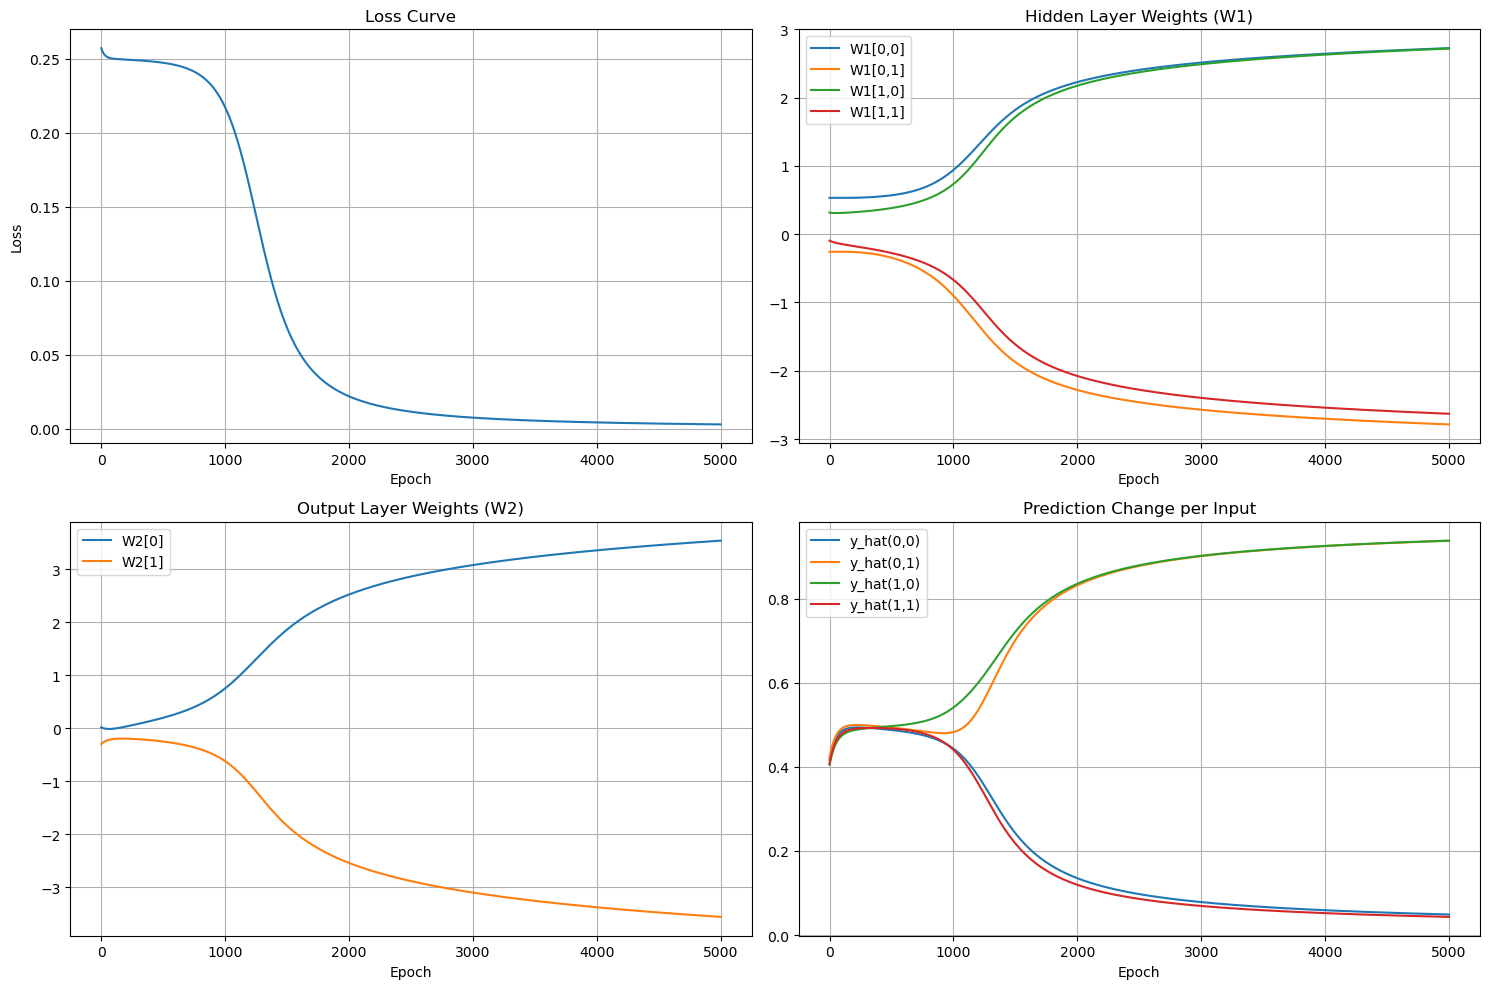

Final Output:
 tensor([[0.0488],
        [0.9381],
        [0.9384],
        [0.0430]], grad_fn=<SigmoidBackward0>)
Final Hidden:
 tensor([[-0.8685,  0.8528],
        [-0.9995, -0.8772],
        [ 0.8850,  0.9993],
        [-0.8826,  0.8754]], grad_fn=<TanhBackward0>)
Final Loss: 0.0029655219987034798


In [1]:
# 그래프에 격자추가

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []

# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록 (매 epoch 저장)
    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 시각화 ======
plt.figure(figsize=(15, 10))

# ---- (1) Loss 그래프 ----
plt.subplot(2, 2, 1)
plt.plot(log_loss)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)   # ← 격자 추가

# ---- (2) W1 변화 ----
W1_arr = torch.tensor(log_W1).numpy()
plt.subplot(2, 2, 2)
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.title("Hidden Layer Weights (W1)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (3) W2 변화 ----
W2_arr = torch.tensor(log_W2).numpy()
plt.subplot(2, 2, 3)
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.title("Output Layer Weights (W2)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

# ---- (4) 출력값 변화 ----
yhat_arr = torch.tensor(log_yhat).numpy()
plt.subplot(2, 2, 4)
plt.plot(yhat_arr[:,0,0], label="y_hat(0,0)")
plt.plot(yhat_arr[:,1,0], label="y_hat(0,1)")
plt.plot(yhat_arr[:,2,0], label="y_hat(1,0)")
plt.plot(yhat_arr[:,3,0], label="y_hat(1,1)")
plt.title("Prediction Change per Input")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)   # ← 격자 추가

plt.tight_layout()
plt.show()


# ====== 7. 최종 결과 ======
final_y, final_h = model(X)
print("Final Output:\n", final_y)
print("Final Hidden:\n", final_h)
print("Final Loss:", criterion(final_y, y).item())


In [2]:
# 아래부터 초기가중치 고정으로 나머지 하이퍼파리미터등은 그대로 둔상태로 코드실행

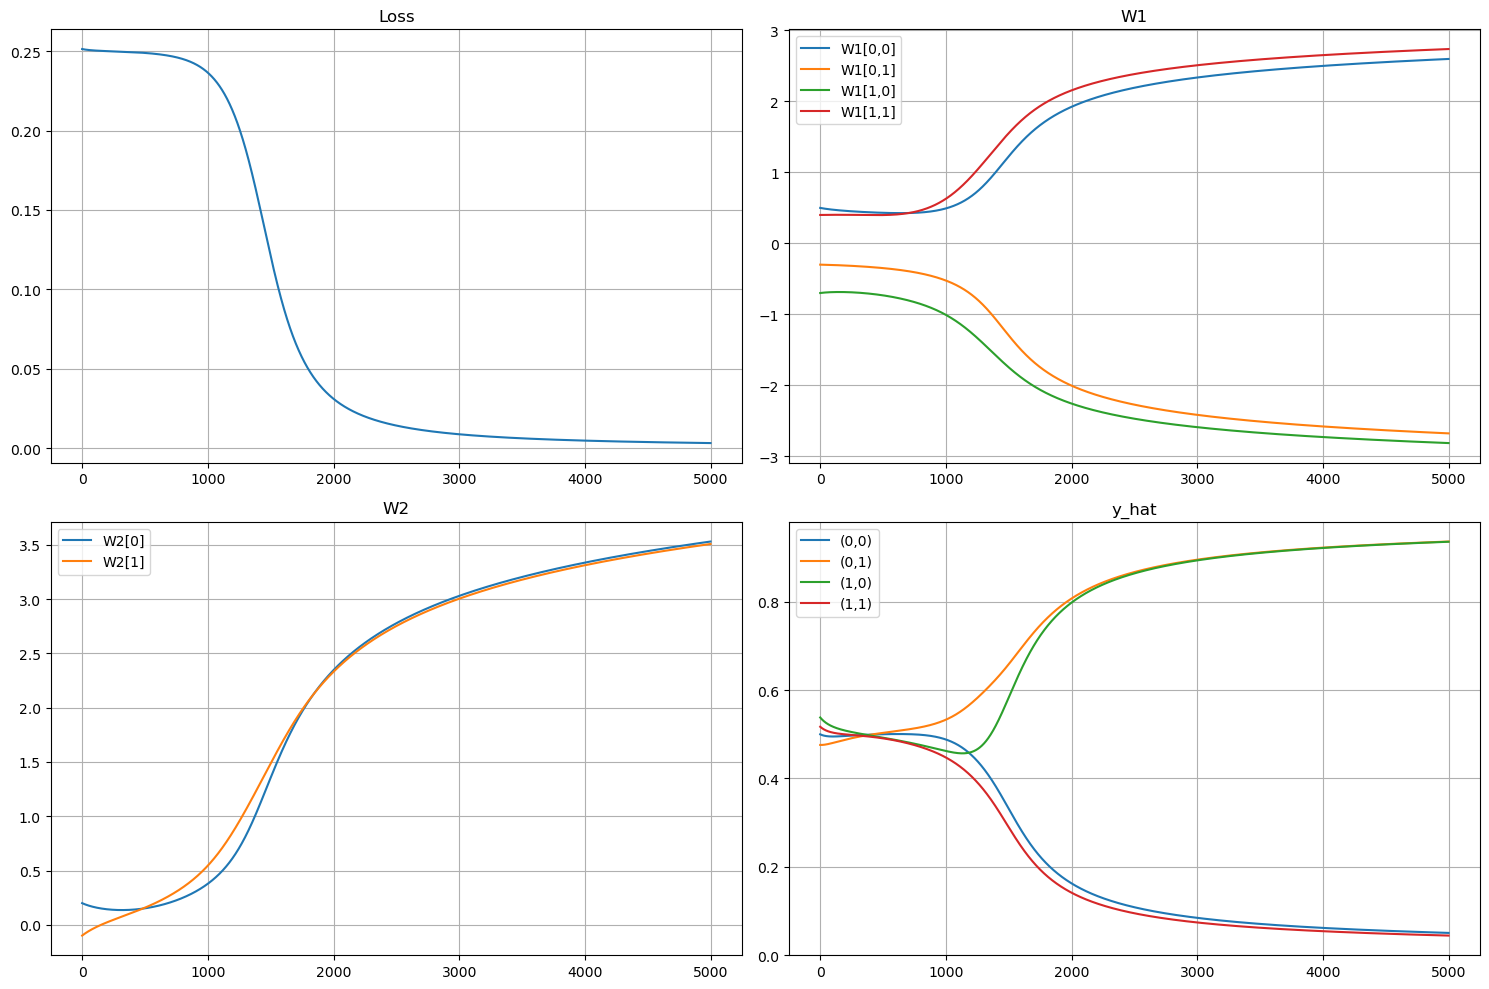

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)  # 랜덤 시드 고정

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

        # ---- 초기 가중치 강제 설정 ----
        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []


# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
plt.plot(log_loss); plt.grid(True); plt.title("Loss")

plt.subplot(2,2,2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.grid(True); plt.title("W1"); plt.legend()

plt.subplot(2,2,3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.grid(True); plt.title("W2"); plt.legend()

plt.subplot(2,2,4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.grid(True); plt.title("y_hat"); plt.legend()

plt.tight_layout()
plt.show()


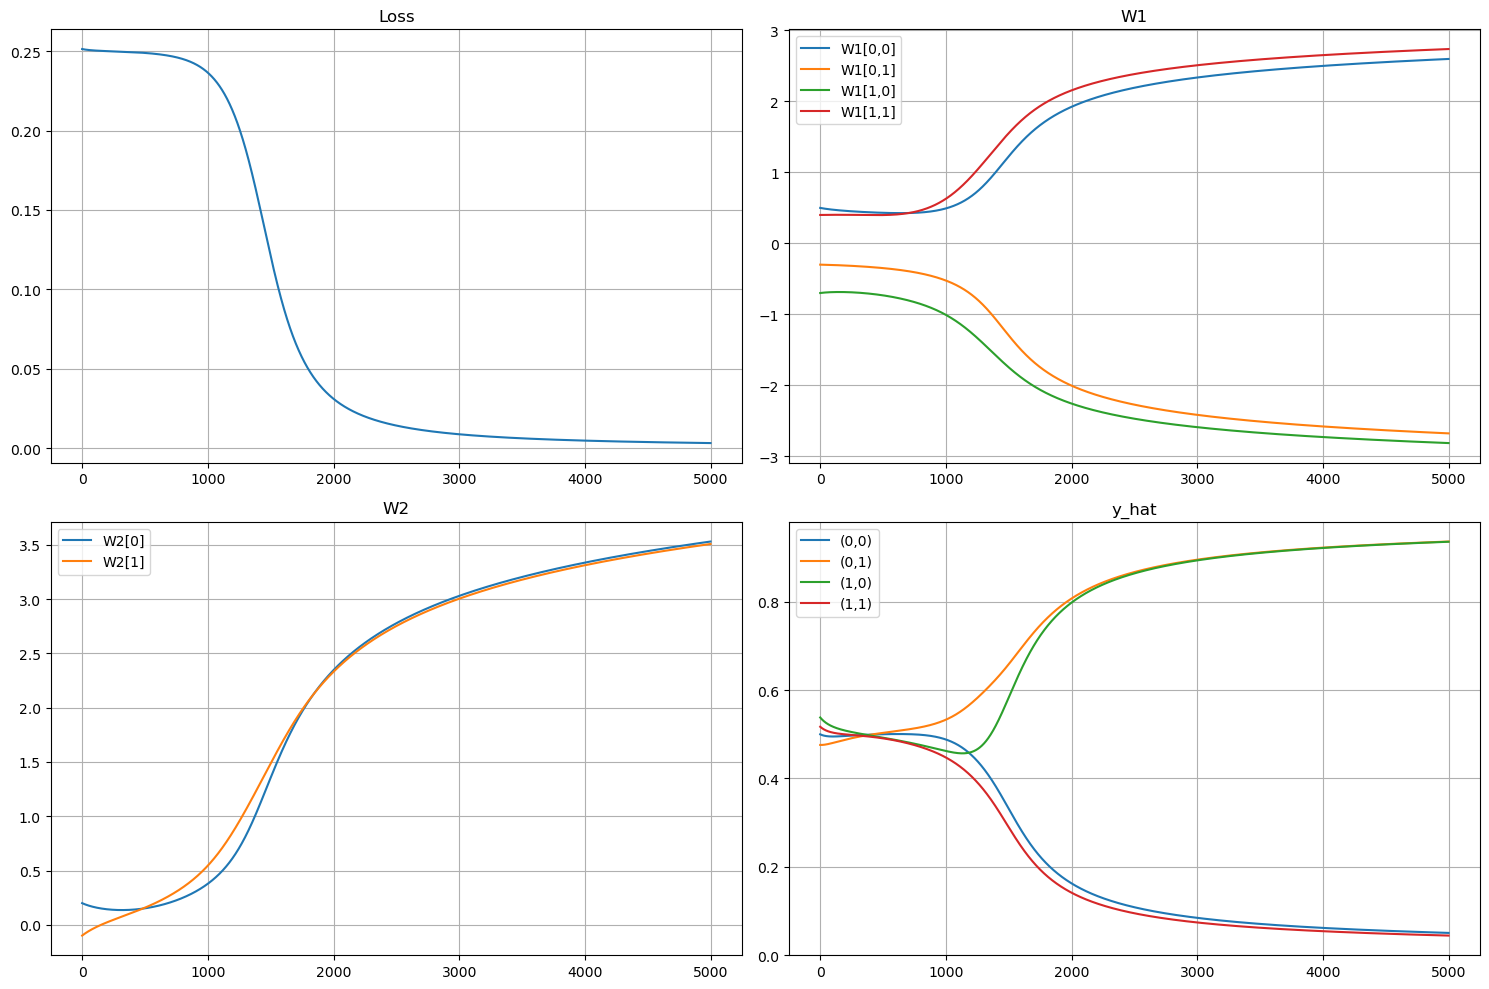

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)  # 랜덤 시드 고정

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

        # ---- 초기 가중치 강제 설정 ----
        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []


# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
plt.plot(log_loss); plt.grid(True); plt.title("Loss")

plt.subplot(2,2,2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.grid(True); plt.title("W1"); plt.legend()

plt.subplot(2,2,3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.grid(True); plt.title("W2"); plt.legend()

plt.subplot(2,2,4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.grid(True); plt.title("y_hat"); plt.legend()

plt.tight_layout()
plt.show()


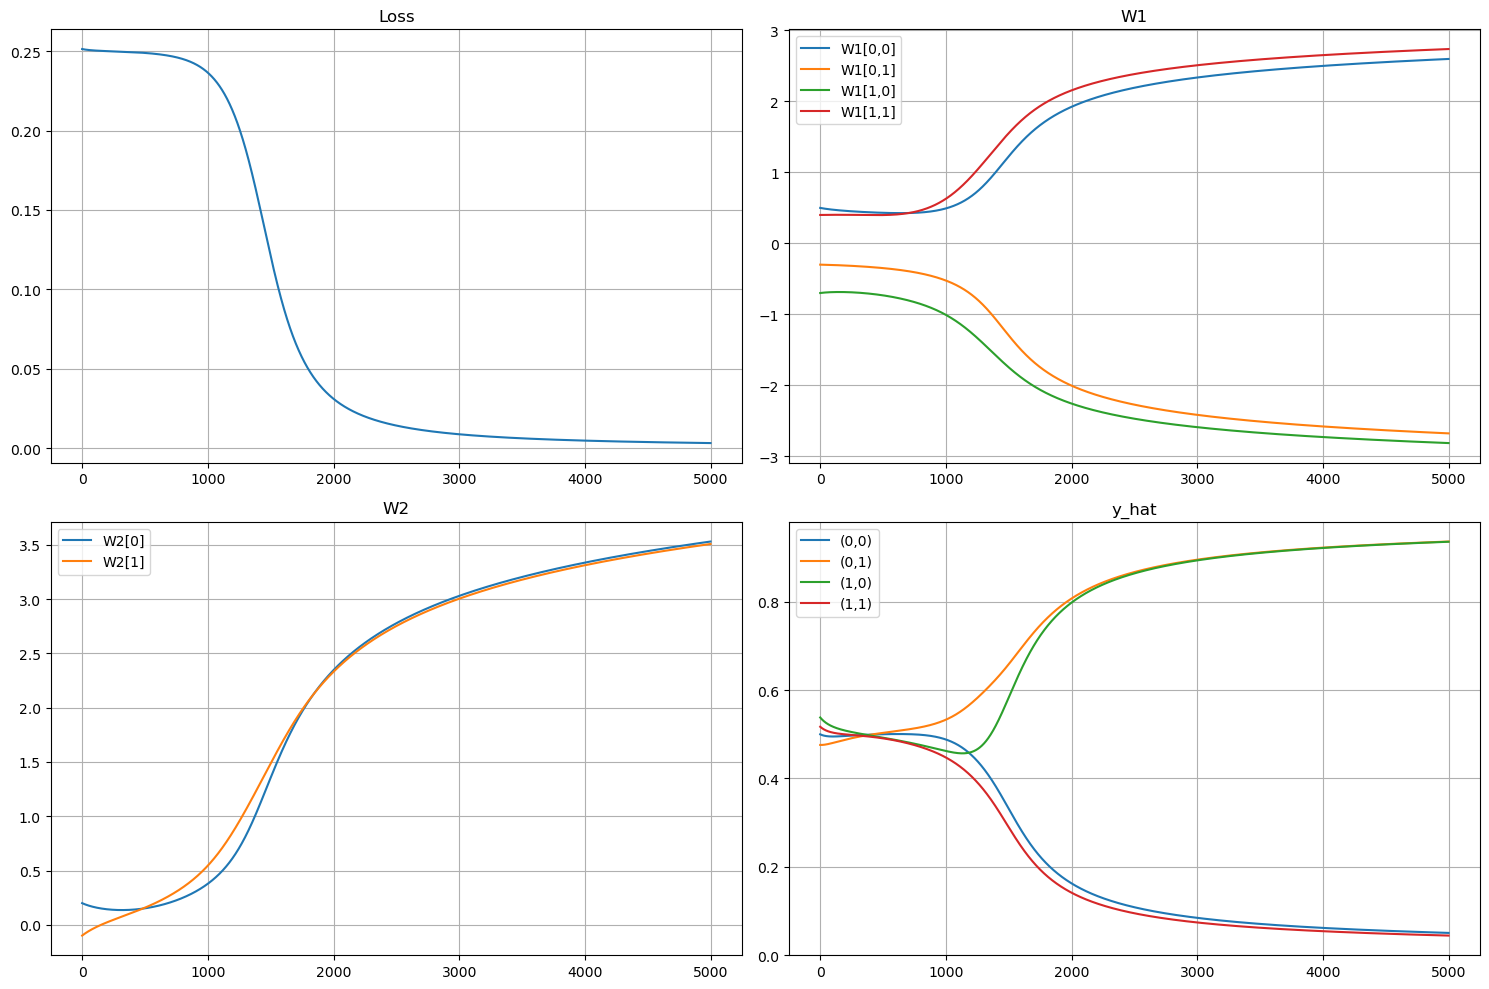

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)  # 랜덤 시드 고정

# ====== 1. 데이터 ======
X = torch.tensor([[0.,0.],
                  [0.,1.],
                  [1.,0.],
                  [1.,1.]], dtype=torch.float32)
y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]], dtype=torch.float32)


# ====== 2. 모델 ======
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Tanh()
        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

        # ---- 초기 가중치 강제 설정 ----
        with torch.no_grad():
            self.fc1.weight.copy_(torch.tensor([[0.5, -0.3],
                                                [-0.7, 0.4]]))
            self.fc1.bias.copy_(torch.tensor([0.0, 0.0]))

            self.fc2.weight.copy_(torch.tensor([[0.2, -0.1]]))
            self.fc2.bias.copy_(torch.tensor([0.0]))

    def forward(self, x):
        h = self.act1(self.fc1(x))
        out = self.act2(self.fc2(h))
        return out, h

model = XORNet()


# ====== 3. 손실 & 옵티마이저 ======
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ====== 4. 기록 ======
epochs = 5000
log_loss = []
log_W1 = []
log_W2 = []
log_yhat = []
log_hidden = []


# ====== 5. 학습 ======
for epoch in range(epochs):

    y_hat, hidden = model(X)
    loss = criterion(y_hat, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    log_loss.append(loss.item())
    log_W1.append(model.fc1.weight.data.clone().numpy())
    log_W2.append(model.fc2.weight.data.clone().numpy())
    log_yhat.append(y_hat.data.clone().numpy())
    log_hidden.append(hidden.data.clone().numpy())


# ====== 6. 그래프 출력 ======
plt.figure(figsize=(15, 10))

plt.subplot(2,2,1)
plt.plot(log_loss); plt.grid(True); plt.title("Loss")

plt.subplot(2,2,2)
W1_arr = torch.tensor(log_W1).numpy()
plt.plot(W1_arr[:,0,0], label="W1[0,0]")
plt.plot(W1_arr[:,0,1], label="W1[0,1]")
plt.plot(W1_arr[:,1,0], label="W1[1,0]")
plt.plot(W1_arr[:,1,1], label="W1[1,1]")
plt.grid(True); plt.title("W1"); plt.legend()

plt.subplot(2,2,3)
W2_arr = torch.tensor(log_W2).numpy()
plt.plot(W2_arr[:,0,0], label="W2[0]")
plt.plot(W2_arr[:,0,1], label="W2[1]")
plt.grid(True); plt.title("W2"); plt.legend()

plt.subplot(2,2,4)
yh = torch.tensor(log_yhat).numpy()
plt.plot(yh[:,0,0], label="(0,0)")
plt.plot(yh[:,1,0], label="(0,1)")
plt.plot(yh[:,2,0], label="(1,0)")
plt.plot(yh[:,3,0], label="(1,1)")
plt.grid(True); plt.title("y_hat"); plt.legend()

plt.tight_layout()
plt.show()
